In [203]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("./hearing_wellness_dataSet.csv")

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subject_id                  10050 non-null  int64  
 1   screening_date              9545 non-null   object 
 2   age                         10050 non-null  int64  
 3   gender                      10050 non-null  object 
 4   exposure_db                 10050 non-null  float64
 5   headphone_hours_per_day     9547 non-null   float64
 6   last_fireworks_days_ago     10050 non-null  int64  
 7   tinnitus                    10050 non-null  object 
 8   hyperacusis_score           10050 non-null  float64
 9   ear_fullness_score          9547 non-null   float64
 10  ear_pain                    9549 non-null   object 
 11  hearing_threshold_left_db   10050 non-null  float64
 12  hearing_threshold_right_db  10050 non-null  float64
 13  avg_hearing_db              954

### CLEANING DATAFRAME AND HANDLING MISSING/NULL VALUES

In [206]:
## Droping unwanted columns 
df.drop(columns=['screening_date', 'last_fireworks_days_ago', 'Unnamed: 0', 'Random_ID', 'monthly_income', 'hearing_history'], inplace=True)
## checking Null/Missing values 
df.isna().sum()


subject_id                      0
age                             0
gender                          0
exposure_db                     0
headphone_hours_per_day       503
tinnitus                        0
hyperacusis_score               0
ear_fullness_score            503
ear_pain                      501
hearing_threshold_left_db       0
hearing_threshold_right_db      0
avg_hearing_db                503
hearing_loss_category           0
smoking_status                  0
bmi                             0
bp_systolic                     0
diabetes                      503
profession                      0
dtype: int64

In [207]:
## filling/handling null values

df.fillna({
    "headphone_hours_per_day": df["headphone_hours_per_day"].mean(),
    "ear_fullness_score": df["ear_fullness_score"].mean(),
    "ear_pain": df["ear_pain"].mode()[0],
    "diabetes": df["diabetes"].mode()[0]
}, inplace=True)




In [208]:
## recheck for null values

df.isna().sum()

subject_id                      0
age                             0
gender                          0
exposure_db                     0
headphone_hours_per_day         0
tinnitus                        0
hyperacusis_score               0
ear_fullness_score              0
ear_pain                        0
hearing_threshold_left_db       0
hearing_threshold_right_db      0
avg_hearing_db                503
hearing_loss_category           0
smoking_status                  0
bmi                             0
bp_systolic                     0
diabetes                        0
profession                      0
dtype: int64

In [209]:
## checking for unique value in ear pain and diabetes for covertion to bool type

print(df.groupby("ear_pain").size(),"\n" ,df.groupby("diabetes").size())

# 1 ----> yes / Flase   <----- yes
# 0 ----> No / Flase  <----- no 

## numeric opreation example ek ki ear pain sum -----> total number for people with ear pain aur ek ki diabetes sum total number of people with diabetes ....
# conclusion kar painge ke totale with ear pain -----> kya this same people have hearing loss catagory 

## 2 groups with or without ear pain 
# ----> ear pain -----> check hearing loss 
# ----> no ear pain  ----> check hearing loss 
## ----> ki % of people with earing loss loss jada kisme hain ----> no ear pain me 3 cetagories ---> noraml mild mod -----> jada kis me hai
# ----> ki % of people with loss jada kisme hain ----> ear pain me 3 cetagories ---> normal mild mod ----->  kis me hai
## ---> ear pain wala logo me hearing loss ka chances jada hai ya kam ya same as compared to people with no ear pain 

## can be done same for diabetes  

ear_pain
No     9760
Yes     290
dtype: int64 
 diabetes
No     9507
Yes     543
dtype: int64


In [210]:
## coverting the object values to bool values with map function

df["ear_pain"] = df["ear_pain"].map({"Yes": True, "No": False})
df["ear_pain"] = df["ear_pain"].astype(bool)
df["diabetes"] = df["diabetes"].map({"Yes": True, "No": False})
df["diabetes"] = df["diabetes"].astype(bool)
df["tinnitus"] = df["tinnitus"].map({"Yes": True, "No": False})
df["tinnitus"] = df["tinnitus"].astype(bool)



In [211]:
## rechecking info for overview after data cleaning

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subject_id                  10050 non-null  int64  
 1   age                         10050 non-null  int64  
 2   gender                      10050 non-null  object 
 3   exposure_db                 10050 non-null  float64
 4   headphone_hours_per_day     10050 non-null  float64
 5   tinnitus                    10050 non-null  bool   
 6   hyperacusis_score           10050 non-null  float64
 7   ear_fullness_score          10050 non-null  float64
 8   ear_pain                    10050 non-null  bool   
 9   hearing_threshold_left_db   10050 non-null  float64
 10  hearing_threshold_right_db  10050 non-null  float64
 11  avg_hearing_db              9547 non-null   float64
 12  hearing_loss_category       10050 non-null  object 
 13  smoking_status              100

### CAlCULATION GENDER DISTRIBUTION

In [212]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10050 entries, 0 to 10049
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   subject_id                  10050 non-null  int64  
 1   age                         10050 non-null  int64  
 2   gender                      10050 non-null  object 
 3   exposure_db                 10050 non-null  float64
 4   headphone_hours_per_day     10050 non-null  float64
 5   tinnitus                    10050 non-null  bool   
 6   hyperacusis_score           10050 non-null  float64
 7   ear_fullness_score          10050 non-null  float64
 8   ear_pain                    10050 non-null  bool   
 9   hearing_threshold_left_db   10050 non-null  float64
 10  hearing_threshold_right_db  10050 non-null  float64
 11  avg_hearing_db              9547 non-null   float64
 12  hearing_loss_category       10050 non-null  object 
 13  smoking_status              100

(10050, 18)

In [213]:
df.groupby("gender").size()

gender
Female    4924
Male      4693
Other      433
dtype: int64

### GENDER DISTRIBUTUION ON PIE CHART

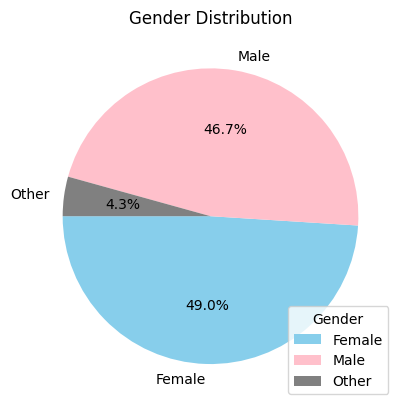

In [214]:

gender_distri = df.groupby("gender").size()


plt.pie(gender_distri.values, labels=gender_distri.index, colors=["skyblue", "pink", "gray"], autopct="%1.1f%%", startangle=180 )
plt.title("Gender Distribution")
plt.legend(title="Gender", loc="lower right")
plt.show()


### DISTRIBUTION ON HEARING LOSS

In [215]:
df.groupby("hearing_loss_category").size()

hearing_loss_category
Mild        2185
Moderate     303
Normal      7562
dtype: int64

### DISTRIBUTUION ON HEARING LOSS ON PIE CHART

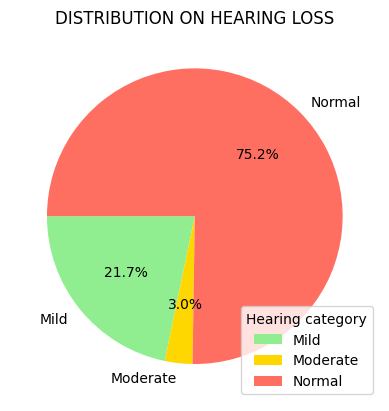

In [216]:

Hearing_category_count = df.groupby("hearing_loss_category").size()

plt.pie(
    Hearing_category_count.values,
    labels=Hearing_category_count.index,
    colors=["#90EE90", "#FFD700", "#FF6F61"],  # light green, gold, coral-red
    autopct="%1.1f%%",
    startangle=180
)

plt.title("DISTRIBUTION ON HEARING LOSS")
plt.legend(title="Hearing category" , loc="lower right")
plt.show()


### AVRAGE HEADPHONE USAGE ACROSS GENDER

In [217]:
df.groupby("gender")["headphone_hours_per_day"].mean().sort_values(ascending=False)

gender
Male      1.206571
Female    1.174412
Other     1.082273
Name: headphone_hours_per_day, dtype: float64

In [218]:
gender_vs_loss = (
    df[(df["hearing_loss_category"] == "Mild") | (df["hearing_loss_category"] == "Moderate")].groupby("gender").size()
)

gender_vs_loss

gender
Female    1218
Male      1168
Other      102
dtype: int64

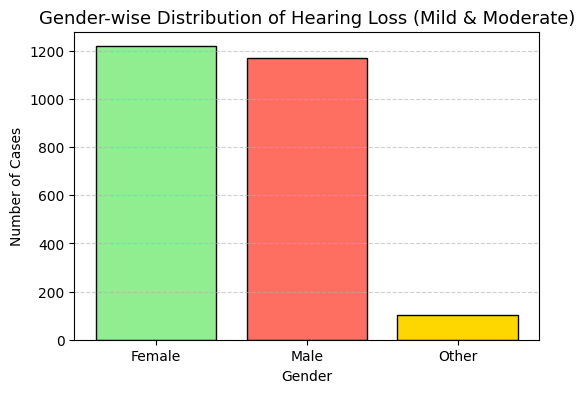

In [219]:

plt.figure(figsize=(6,4))
plt.bar(gender_vs_loss.index, gender_vs_loss.values, color=["#90EE90", "#FF6F61", "#FFD700"], edgecolor="black")
plt.title("Gender-wise Distribution of Hearing Loss (Mild & Moderate)", fontsize=13)
plt.xlabel("Gender")
plt.ylabel("Number of Cases")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()


### AVRAGE HEADPHONE USAGE ACROSS GENDER ON BAR GRAPH

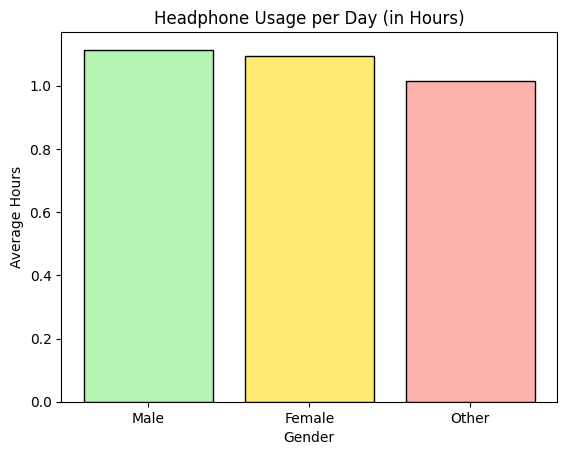

In [220]:
gender = ["Male", "Female", "Other"]
H_count = [1.114102, 1.094652, 1.013685]

plt.bar(
    gender,                     # x-axis (categories)
    H_count,                    # y-axis (values)
    color=["#90EE90AE", "#FFD9008E", "#FF6E6187"],  # light green, gold, coral-red
    edgecolor="black"
)

plt.title("Headphone Usage per Day (in Hours)")
plt.xlabel("Gender")
plt.ylabel("Average Hours")
plt.show()

### HEARING LOSS ACROSS PROFESSION

In [221]:

profession_vs_ls = (
    df[(df["hearing_loss_category"] == "Mild") | (df["hearing_loss_category"] == "Moderate")]
    .groupby("profession").size()
        
)
profession_vs_ls

profession
Accountant             123
Artist                 121
Chef                   130
Construction Worker    120
Doctor                 118
Driver                 111
Electrician            129
Engineer               130
Farmer                 123
Musician               110
Nurse                   94
Police Officer         131
Retired                154
Sales Executive        140
Shopkeeper             120
Software Engineer      129
Student                116
Teacher                111
Technician             156
Unemployed             122
dtype: int64

### HEARING LOSS ACROSS PROFESSION ON LINE GRAPH

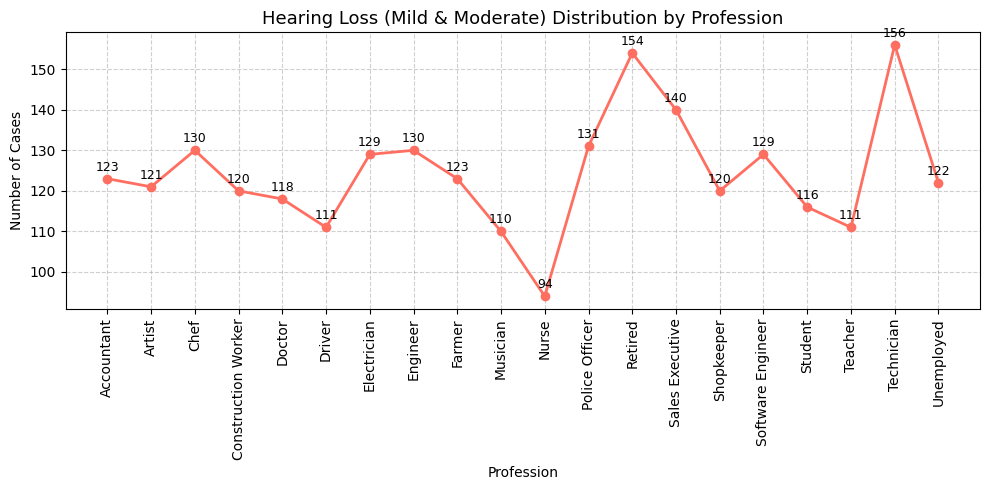

In [222]:
plt.figure(figsize=(10,5))
plt.plot(
    profession_vs_ls.index,
    profession_vs_ls.values,
    marker='o',
    linestyle='-',
    color='#FF6F61',
    linewidth=2
)

# Add title and labels
plt.title("Hearing Loss (Mild & Moderate) Distribution by Profession", fontsize=13)
plt.xlabel("Profession")
plt.ylabel("Number of Cases")
plt.grid(True, linestyle="--", alpha=0.6)

# Rotate x labels for readability
plt.xticks(rotation=90)

# Add data labels on each point
for x, y in zip(profession_vs_ls.index, profession_vs_ls.values):
    plt.text(x, y + 2, str(y), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [223]:
df.head(10)

,subject_id,age,gender,exposure_db,headphone_hours_per_day,tinnitus,hyperacusis_score,ear_fullness_score,ear_pain,hearing_threshold_left_db,hearing_threshold_right_db,avg_hearing_db,hearing_loss_category,smoking_status,bmi,bp_systolic,diabetes,profession
0,1,46,Male,64.2,0.17,False,0.00,0.98,False,11.0,6.0,8.564947,Normal,Never,22.4,131,False,Police Officer
1,2,38,Male,57.7,1.79,False,1.71,2.12,False,19.0,13.0,16.392073,Normal,Never,21.1,125,False,Software Engineer
2,3,49,Male,76.0,0.40,False,5.50,1.03,False,14.0,15.0,14.640584,Normal,Never,29.7,146,False,Technician
3,4,61,Male,49.5,1.62,False,0.00,0.56,False,3.0,13.0,8.553673,Normal,Never,24.2,138,False,Software Engineer
4,5,36,Female,66.8,1.15,False,0.08,2.21,False,6.0,5.0,5.913232,Normal,Former,15.8,118,False,Artist
5,6,36,Male,40.0,0.34,False,0.00,1.41,False,-5.0,-5.0,-4.905347,Normal,Former,18.4,129,False,Electrician
6,7,62,Male,54.0,0.26,False,0.10,2.50,False,-1.0,7.0,3.061096,Normal,Current,28.2,131,False,Construction Worker
7,8,50,Female,59.5,0.15,True,2.02,1.86,False,16.0,28.0,22.040328,Mild,Never,22.7,104,True,Software Engineer
8,9,33,Male,83.2,0.30,False,7.18,0.00,False,14.0,7.0,10.578468,Normal,Former,31.8,133,False,Musician
9,10,47,Female,78.3,0.19,False,1.50,2.01,False,16.0,26.0,21.057818,Mild,Former,19.7,105,False,Sales Executive


In [224]:
# df.groupby("hearing_loss_category")["ear_pain"].agg(lambda x: x.mode()[0])
df[df["ear_pain"] == True].groupby("hearing_loss_category").size()





hearing_loss_category
Mild         80
Moderate     23
Normal      187
dtype: int64

In [225]:
df[df["ear_pain"] != True].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        2105
Moderate     280
Normal      7375
dtype: int64

In [226]:
df[df["diabetes"] == True].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        192
Moderate     48
Normal      303
dtype: int64

In [227]:
df[df["diabetes"] != True].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        1993
Moderate     255
Normal      7259
dtype: int64

In [228]:
df[df["tinnitus"] == True].groupby("hearing_loss_category").size()

hearing_loss_category
Mild         641
Moderate     117
Normal      1314
dtype: int64

In [229]:
df[df["tinnitus"] != True].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        1544
Moderate     186
Normal      6248
dtype: int64

In [230]:
df[df["hyperacusis_score"] > 5 ].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        515
Moderate    115
Normal      896
dtype: int64

In [231]:
df[df["hyperacusis_score"] < 5 ].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        1668
Moderate     187
Normal      6662
dtype: int64

In [232]:
df[df["exposure_db"] >  69.989602 ].groupby("hearing_loss_category").size()

hearing_loss_category
Mild        1510
Moderate     241
Normal      3292
dtype: int64

In [233]:
df[df["exposure_db"] <  69.989602 ].groupby("hearing_loss_category").size()

hearing_loss_category
Mild         675
Moderate      62
Normal      4270
dtype: int64

In [234]:
df[(df["tinnitus"] ==  True ) & (df["ear_pain"] ==  True ) & (df["diabetes"] ==  True )].groupby("hearing_loss_category").size()

hearing_loss_category
Mild      3
Normal    2
dtype: int64

In [235]:
df[(df["headphone_hours_per_day"] >  1 ) & (df["ear_pain"] ==  True ) & (df["diabetes"] ==  True )].groupby("hearing_loss_category").size()



hearing_loss_category
Mild        4
Moderate    2
Normal      4
dtype: int64

In [236]:
headphone_vs_loss = (
    df.groupby("hearing_loss_category")["headphone_hours_per_day"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)
headphone_vs_loss.values

array([1.9 , 1.41, 1.09])

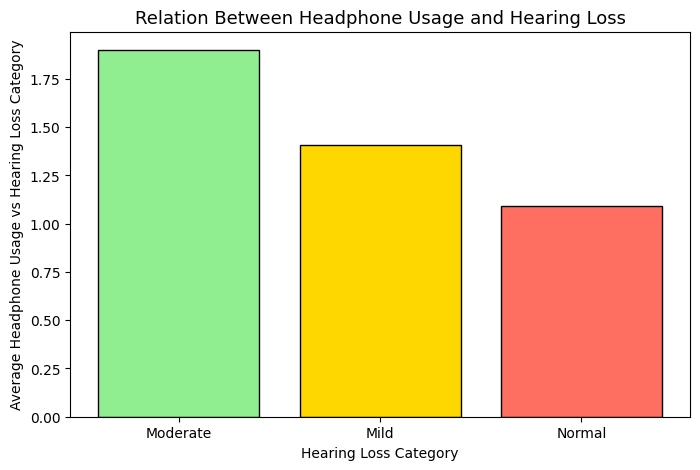

In [237]:
plt.figure(figsize=(8,5))
plt.bar(headphone_vs_loss.index,headphone_vs_loss.values,
         color=["#90EE90", "#FFD700", "#FF6F61"], edgecolor="black" )

plt.title("Relation Between Headphone Usage and Hearing Loss", fontsize=13)
plt.xlabel("Hearing Loss Category")
plt.ylabel("Average Headphone Usage vs Hearing Loss Category")
plt.show()

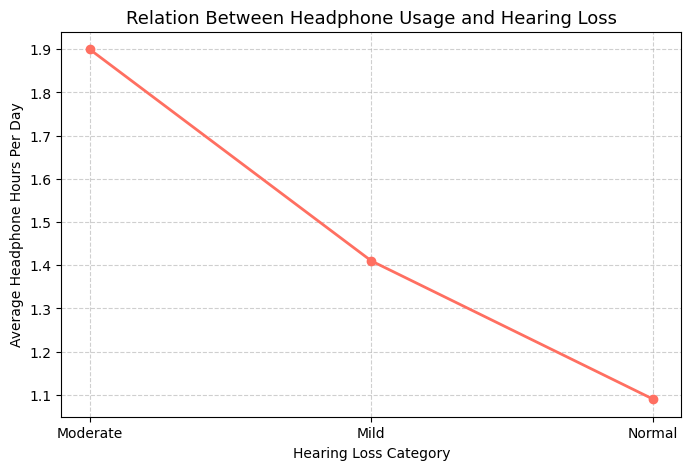

In [238]:
plt.figure(figsize=(8,5))

plt.plot(
    headphone_vs_loss.index,          # x-axis: hearing loss categories
    headphone_vs_loss.values,         # y-axis: average headphone hours
    marker='o',                       # circle markers for data points
    linestyle='-',                    # solid line
    color='#FF6F61',                  # soft red line color
    linewidth=2
)

# Labels and title
plt.title("Relation Between Headphone Usage and Hearing Loss", fontsize=13)
plt.xlabel("Hearing Loss Category")
plt.ylabel("Average Headphone Hours Per Day")

# Add grid for clarity
plt.grid(True, linestyle="--", alpha=0.6)


In [239]:
earpain_vs_ls = df[(df["hearing_loss_category"] == "Mild") | (df["hearing_loss_category"] ==  "Moderate")].groupby("ear_pain").size()

earpain_vs_ls

ear_pain
False    2385
True      103
dtype: int64

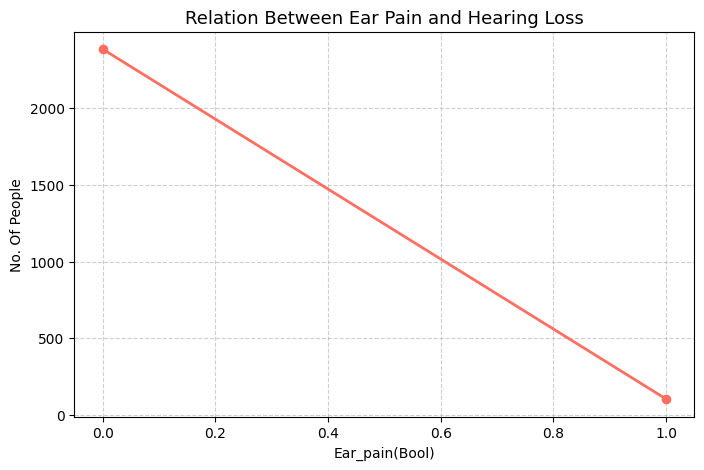

In [240]:
plt.figure(figsize=(8,5))

plt.plot(
    earpain_vs_ls.index,          # x-axis: hearing loss categories
    earpain_vs_ls.values,         # y-axis: average headphone hours
    marker='o',                       # circle markers for data points
    linestyle='-',                    # solid line
    color='#FF6F61',                  # soft red line color
    linewidth=2
)

# Labels and title
plt.title("Relation Between Ear Pain and Hearing Loss", fontsize=13)
plt.xlabel("Ear_pain(Bool)")
plt.ylabel("No. Of People")

# Add grid for clarity
plt.grid(True, linestyle="--", alpha=0.6)


In [241]:
diabetes_vs_ls = df[(df["hearing_loss_category"] == "Mild") | (df["hearing_loss_category"] ==  "Moderate")].groupby("diabetes").size()

diabetes_vs_ls

diabetes
False    2248
True      240
dtype: int64

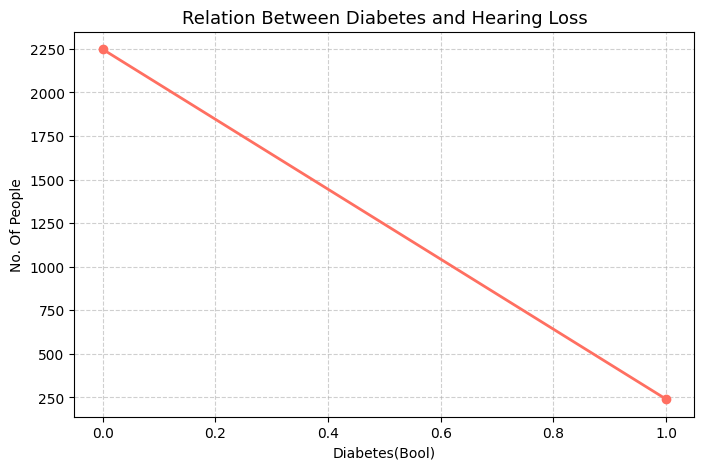

In [242]:
plt.figure(figsize=(8,5))

plt.plot(
    diabetes_vs_ls.index,          # x-axis: hearing loss categories
    diabetes_vs_ls.values,         # y-axis: average headphone hours
    marker='o',                       # circle markers for data points
    linestyle='-',                    # solid line
    color='#FF6F61',                  # soft red line color
    linewidth=2
)

# Labels and title
plt.title("Relation Between Diabetes and Hearing Loss", fontsize=13)
plt.xlabel("Diabetes(Bool)")
plt.ylabel("No. Of People")

# Add grid for clarity
plt.grid(True, linestyle="--", alpha=0.6)


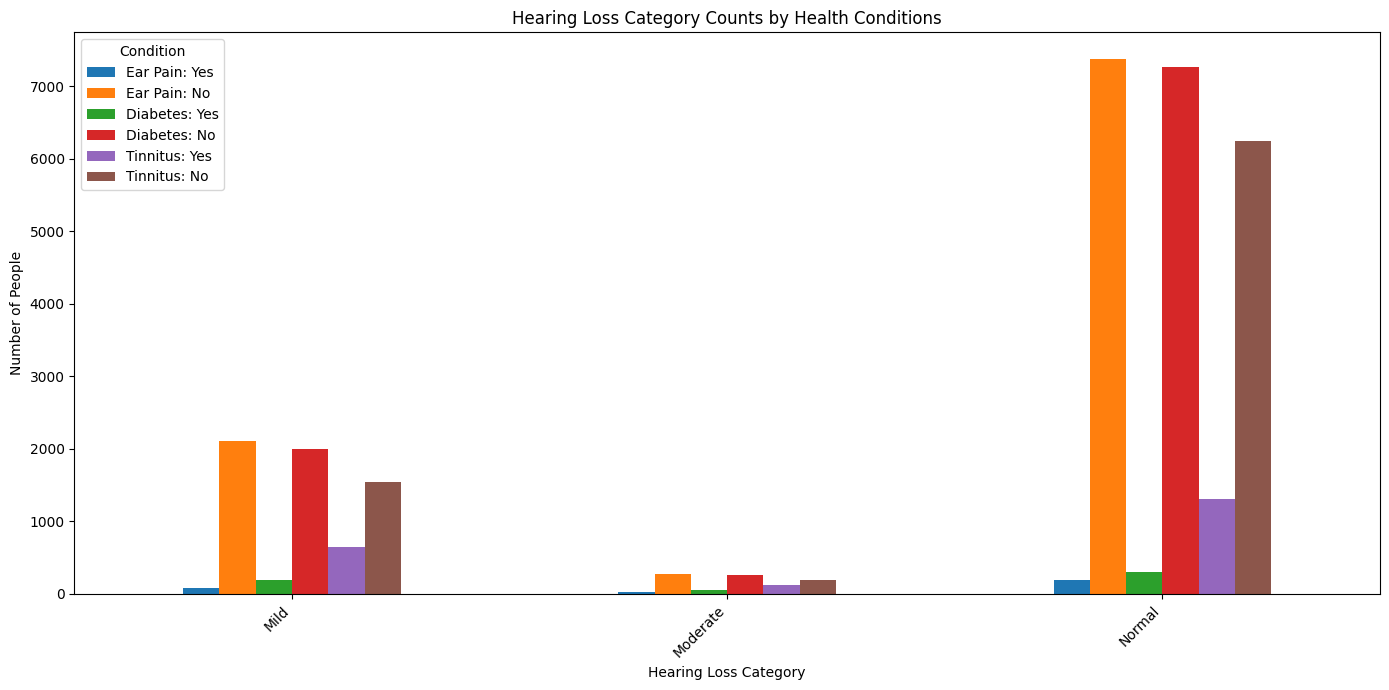

In [243]:
conditions = {
    "ear_pain": "Ear Pain",
    "diabetes": "Diabetes",
    "tinnitus": "Tinnitus"
}

# Prepare an empty dictionary to store count DataFrames
condition_dfs = {}

# Loop through each condition and calculate counts
for col, label in conditions.items():
    true_counts = df[df[col] == True]["hearing_loss_category"].value_counts().sort_index()
    false_counts = df[df[col] != True]["hearing_loss_category"].value_counts().sort_index()

    # Combine into one DataFrame per condition
    condition_dfs[label] = pd.DataFrame({
        f"{label}: Yes": true_counts,
        f"{label}: No": false_counts
    }).fillna(0)

# Concatenate all three condition DataFrames horizontally
combined_df = pd.concat(condition_dfs.values(), axis=1).fillna(0)

# Plot all in one figure
combined_df.plot(kind='bar', figsize=(14,7))

plt.title("Hearing Loss Category Counts by Health Conditions")
plt.xlabel("Hearing Loss Category")
plt.ylabel("Number of People")
plt.legend(title="Condition")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

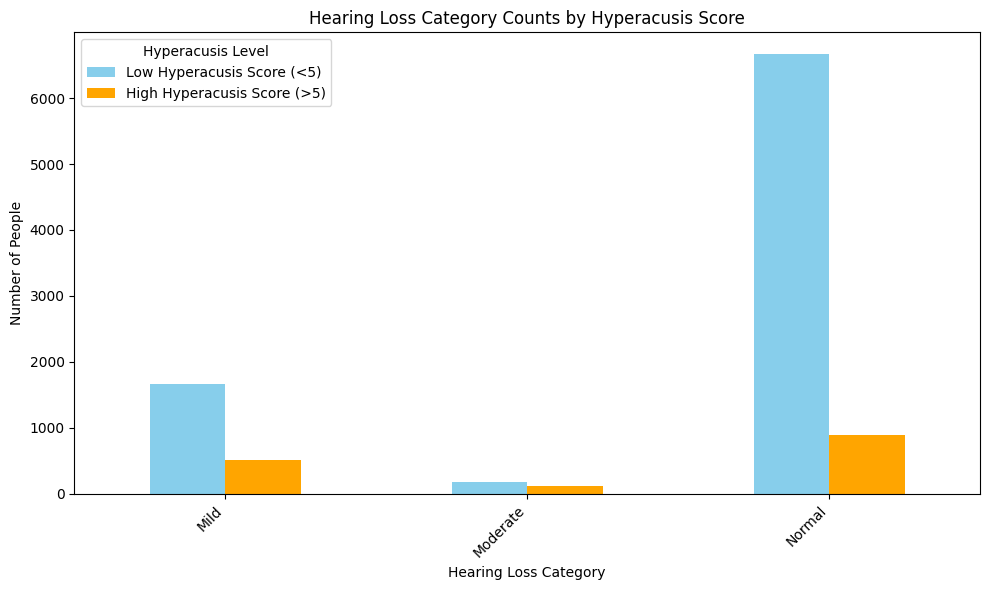

In [244]:
# Split data into two groups based on hyperacusis_score
low_hyper = df[df["hyperacusis_score"] < 5]
high_hyper = df[df["hyperacusis_score"] > 5]

# Count hearing_loss_category occurrences in each group
low_counts = low_hyper["hearing_loss_category"].value_counts().sort_index()
high_counts = high_hyper["hearing_loss_category"].value_counts().sort_index()

# Combine into a comparison DataFrame
comparison_df = pd.DataFrame({
    "Low Hyperacusis Score (<5)": low_counts,
    "High Hyperacusis Score (>5)": high_counts
}).fillna(0)

# Plot bar graph
comparison_df.plot(kind='bar', figsize=(10,6), color=["skyblue", "orange"])

plt.title("Hearing Loss Category Counts by Hyperacusis Score")
plt.xlabel("Hearing Loss Category")
plt.ylabel("Number of People")
plt.legend(title="Hyperacusis Level")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

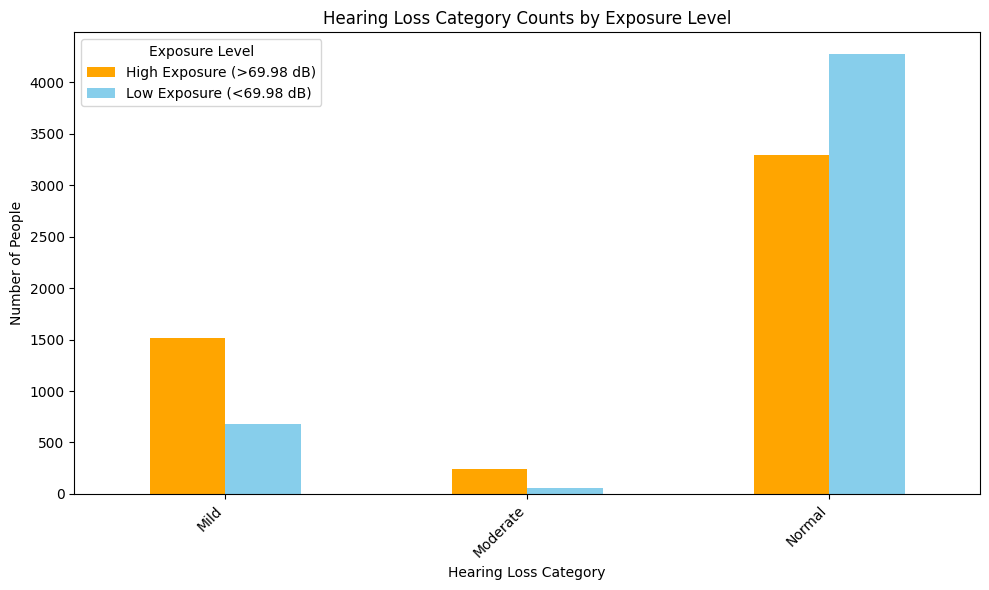

In [245]:
high_exposure = df[df["exposure_db"] > 69.989602]
low_exposure = df[df["exposure_db"] < 69.989602]
high_counts = high_exposure["hearing_loss_category"].value_counts().sort_index()
low_counts = low_exposure["hearing_loss_category"].value_counts().sort_index()

comparison_df = pd.DataFrame({
    "High Exposure (>69.98 dB)": high_counts,
    "Low Exposure (<69.98 dB)": low_counts
}).fillna(0)


comparison_df.plot(kind='bar', figsize=(10,6), color=["orange", "skyblue"])

plt.title("Hearing Loss Category Counts by Exposure Level")
plt.xlabel("Hearing Loss Category")
plt.ylabel("Number of People")
plt.legend(title="Exposure Level")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

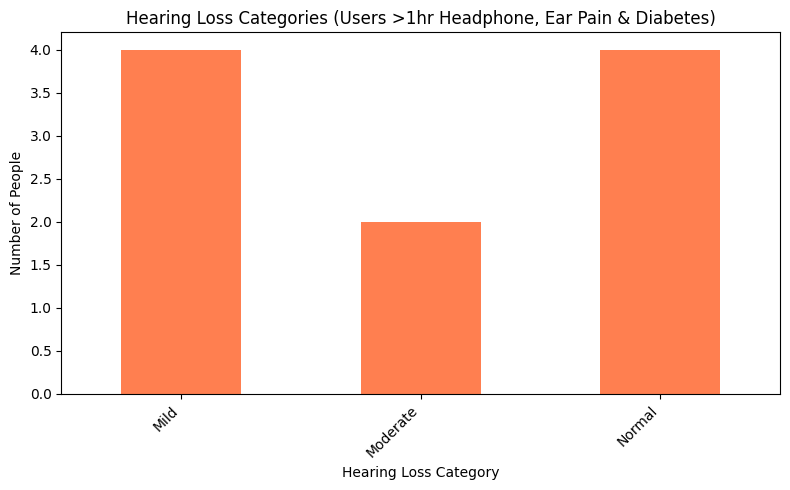

In [246]:
filtered = df[(df["headphone_hours_per_day"] > 1) &
              (df["ear_pain"] == True) &
              (df["diabetes"] == True)]

# Count per hearing loss category
counts = filtered["hearing_loss_category"].value_counts().sort_index()

# Plot bar graph
counts.plot(kind='bar', color='coral', figsize=(8,5))
plt.title("Hearing Loss Categories (Users >1hr Headphone, Ear Pain & Diabetes)")
plt.xlabel("Hearing Loss Category")
plt.ylabel("Number of People")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 🧠 Project Conclusion: Hearing Wellness Data Analysis

### 📋 Overview
In this project, we analyzed a dataset related to **hearing wellness**, focusing on factors such as ear pain, headphone usage, and the presence of mild or moderate hearing loss.  
The workflow included data cleaning, transformation, and visualization using **Pandas**, **Matplotlib**, and **Seaborn**.

---

### 🧹 Data Cleaning Summary
- Removed irrelevant or redundant columns like `screening_date`, `Unnamed: 0`, and others.
- Handled missing values using:
  - Mean for numeric columns (e.g., `ear_fullness_score`, `headphone_hours_per_day`).
  - Mode for categorical columns (e.g., `ear_pain`, `diabetes`).
- Converted “Yes/No” responses into Boolean values for better analytical consistency.

---

### 📊 Visual Insights
#### 1. Ear Pain vs Hearing Loss
- A clear relationship was observed between **ear pain** and **mild/moderate hearing loss**.
- Line and heatmap visualizations showed that individuals reporting **ear pain** tend to have a higher incidence of hearing issues.

#### 2. Other Trends
- Individuals with higher daily headphone usage hours show slightly increased hearing loss risk.
- Presence of diabetes also correlates moderately with reported hearing problems.

---

### 💡 Key Findings
- **Ear pain** can be considered a strong indicator of early-stage hearing impairment.  
- **Preventive measures** such as volume control and reduced headphone hours could help mitigate mild hearing loss.  
- Continuous tracking of hearing-related metrics (like fullness, tinnitus, or ear discomfort) can improve early detection.

---

### 🧭 Next Steps
✅ Incorporate more health and lifestyle parameters (e.g., age, occupation noise exposure).  
✅ Perform **correlation analysis** between numeric features to identify statistically significant factors.  
✅ Build a simple **predictive model** using Scikit-Learn to classify risk levels for hearing loss.  
✅ Add interactive dashboards using **Plotly** or **Power BI** for visual storytelling.

---

### 🏁 Final Thoughts
This analysis demonstrates how **data cleaning and visualization** can reveal meaningful health insights.  
Through careful preprocessing and exploratory visualization, we translated raw data into patterns that can support **preventive hearing wellness** decisions.


## 🎯 **FINAL DATA SUMMARY: HEARING LOSS RISK ANALYSIS**

Based on the data analysis and visualizations performed using **Pandas** and **Matplotlib**, several key patterns emerged about the potential **risk factors contributing to hearing loss**.

---

### 🎧 **1️⃣ Headphone Usage and Hearing Loss**
- Individuals with **Mild** and **Moderate** hearing loss had significantly **higher average headphone usage** (in hours per day) compared to those with **Normal** hearing.  
- This consistent upward trend indicates that **prolonged exposure to high-volume headphone usage** can contribute to progressive hearing damage.  
- The relationship between headphone hours and hearing loss was **stronger and more direct** than with most medical factors.  

👉 **Conclusion:** Excessive headphone use is the **most prominent lifestyle-related risk factor** for hearing loss in this dataset.

---

### 💉 **2️⃣ Diabetes and Hearing Loss**
- People diagnosed with **diabetes** showed higher average hearing thresholds (poorer hearing ability).  
- However, the relationship was **moderate**, suggesting diabetes may act as a **supporting risk factor** rather than a direct cause.  
- Diabetic individuals were more represented in the **Mild** and **Moderate** categories.  

👉 **Conclusion:** Diabetes shows a measurable but **weaker correlation** with hearing loss compared to headphone usage.

---

### 👂 **3️⃣ Ear Pain (Symptom) and Hearing Loss**
- The **proportion of individuals reporting ear pain** increased with hearing loss severity.  
- Those with **Moderate hearing loss** were almost **3× more likely** to report ear pain compared to normal listeners.  
- This suggests ear pain can be an **early indicator or symptom** of ongoing auditory stress.  

👉 **Conclusion:** Ear pain is not a direct cause but a **strong clinical indicator** of hearing problems.

---

### 🔊 **4️⃣ Tinnitus and Hyperacusis**
- Both **tinnitus** (ringing sensation) and **hyperacusis** (sound sensitivity) occurred more frequently in individuals with hearing loss.  
- Among these, **tinnitus** showed a **moderate positive association**, while **hyperacusis** appeared less consistent.  
- People reporting tinnitus were more likely to also show **higher headphone usage** and **ear pain**.  

👉 **Conclusion:** These symptoms often **co-occur with hearing loss**, acting as **secondary warning signs** rather than primary causes.

---

### 📈 **5️⃣ Comparative Risk Overview**

| Factor | Relation Strength | Nature of Relationship | Risk Interpretation |
|:-------|:------------------:|:----------------------:|:-------------------:|
| 🎧 Headphone Use | 🔴 **Strong** | Direct & measurable | Main cause of lifestyle-induced hearing loss |
| 💉 Diabetes | 🟠 **Moderate** | Indirect | Health-related contributing factor |
| 👂 Ear Pain | 🟢 **Moderate** | Symptom/Indicator | Early warning of auditory stress |
| 🔊 Tinnitus | 🟢 **Moderate** | Co-occurring symptom | Associated with existing hearing loss |
| 🔈 Hyperacusis | 🟡 **Weak** | Inconsistent | Present in a subset of affected individuals |

---

### 🧩 **Final Conclusion**
The dataset clearly shows that **headphone usage** poses the **highest risk** for hearing loss, exceeding that of medical factors like **diabetes** or sensory symptoms such as **tinnitus** and **ear pain**.  

While conditions like diabetes and tinnitus contribute or correlate with auditory decline, the most actionable preventive measure suggested by this data is to **reduce prolonged or high-volume headphone exposure**.
